```
why does nit the perivous code work

the pervious messgae does be visible know
it is having no memory
sesion state solve  this problem
all information will erase only when we refreash the page
```

```
so insead of using this  message_history = []  >>> simple list
we use >> session state
session state is dictionary >> itself >> first it willbe empty  

```

In [11]:
!pip install streamlit pyngrok -q
!pip install -q langgraph langchain langchain-core langchain-groq python-dotenv

In [12]:
%%writefile app.py
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage
import streamlit as st

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=""
)

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

checkpointer = InMemorySaver()
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)
chatbot = graph.compile(checkpointer=checkpointer)

CONFIG = {'configurable': {'thread_id': 'thread-1'}}

if 'message_history' not in st.session_state:
    st.session_state['message_history'] = []

# this is for displaying the messgae
# i guess here the messgae is disply wapse the pervious converstaion
for message in st.session_state['message_history']:
    with st.chat_message(message['role']):
        st.text(message['content'])

user_input = st.chat_input('Type here')

if user_input:
   # adding user messgae for session._state
    st.session_state['message_history'].append({'role': 'user', 'content': user_input})
    with st.chat_message('user'):
        st.text(user_input)
     #big change here we want to diplay ai message
    response = chatbot.invoke({'messages': [HumanMessage(content=user_input)]}, config=CONFIG)

    ai_message = response['messages'][-1].content
    # first add the message to message_history
    st.session_state['message_history'].append({'role': 'assistant', 'content': ai_message})
    with st.chat_message('assistant'):
        st.text(ai_message)
        #this code is for icon who is it , is it user or is it ai
    # in this code we tell him it is assistant mean si
        #this create the tet box and add ai messgae it in
        # here instaed of user_input we do ai_message

Overwriting app.py


In [13]:
!streamlit run app.py &>/content/logs.txt &

In [14]:
from google.colab import userdata
from pyngrok import ngrok
import time

pyngrok_token = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(pyngrok_token)

time.sleep(3)
public_url = ngrok.connect(addr=8501)
print(public_url)

NgrokTunnel: "https://thrower-curvature-rigid.ngrok-free.dev" -> "http://localhost:8501"


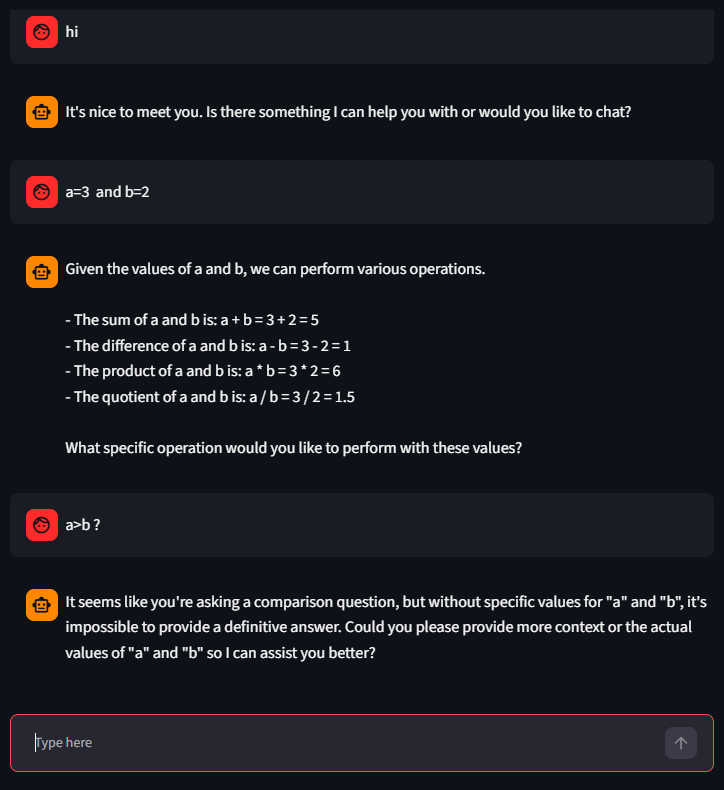